Initial data shape: (5572, 2)
Classes after label encoding: {np.int64(0): np.int64(0), np.int64(1): np.int64(1)}

Class counts before balancing:
label
0    4825
1     747
Name: count, dtype: int64

Class counts after balancing:
label
1    747
0    747
Name: count, dtype: int64


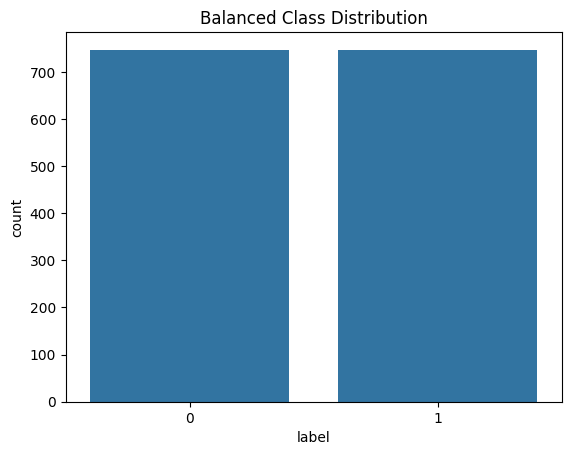

Using device: cuda

TRAINING WITH MLP ALTERNATIVE

TRAINING WITH SEED = 42
Alternative Type: MLP


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Using Two-Unit MLP with Tanh activation

Model parameters: Total=184,795,926, Trainable=184,795,926
Epoch 1/5 | Train Loss: 0.6668 | Train Acc: 0.5692 | Val Loss: 0.5934 | Val Acc: 0.8784 | Time: 42.88s
Epoch 2/5 | Train Loss: 0.5865 | Train Acc: 0.8520 | Val Loss: 0.4975 | Val Acc: 0.9219 | Time: 39.80s
Epoch 3/5 | Train Loss: 0.5073 | Train Acc: 0.9227 | Val Loss: 0.4549 | Val Acc: 0.9094 | Time: 41.16s
Epoch 4/5 | Train Loss: 0.4619 | Train Acc: 0.9219 | Val Loss: 0.4074 | Val Acc: 0.9250 | Time: 40.57s
Epoch 5/5 | Train Loss: 0.4241 | Train Acc: 0.9441 | Val Loss: 0.3920 | Val Acc: 0.9344 | Time: 40.68s

TRAINING WITH SINCOS ALTERNATIVE

TRAINING WITH SEED = 42
Alternative Type: SINCOS


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Using Sin/Cos Feature Map

Model parameters: Total=184,796,078, Trainable=184,796,078
Epoch 1/5 | Train Loss: 0.6644 | Train Acc: 0.7066 | Val Loss: 0.5926 | Val Acc: 0.8628 | Time: 40.94s
Epoch 2/5 | Train Loss: 0.5845 | Train Acc: 0.8759 | Val Loss: 0.5057 | Val Acc: 0.9125 | Time: 40.84s
Epoch 3/5 | Train Loss: 0.5164 | Train Acc: 0.9146 | Val Loss: 0.4473 | Val Acc: 0.9219 | Time: 40.66s
Epoch 4/5 | Train Loss: 0.4714 | Train Acc: 0.9113 | Val Loss: 0.4206 | Val Acc: 0.9156 | Time: 40.59s
Epoch 5/5 | Train Loss: 0.4344 | Train Acc: 0.9376 | Val Loss: 0.4010 | Val Acc: 0.9250 | Time: 40.74s

COMPREHENSIVE METRICS: MLP vs SinCos Feature Map (Single Seed 42)
Alternative  Accuracy     Precision    Recall       Specificity    F1-Score     AUC       
-------------------------------------------------------------------------------------
MLP          0.9298       0.9298       0.9298       0.9333         0.9298       0.9563    
SINCOS       0.9197       0.9204       0.9197       0.9400      

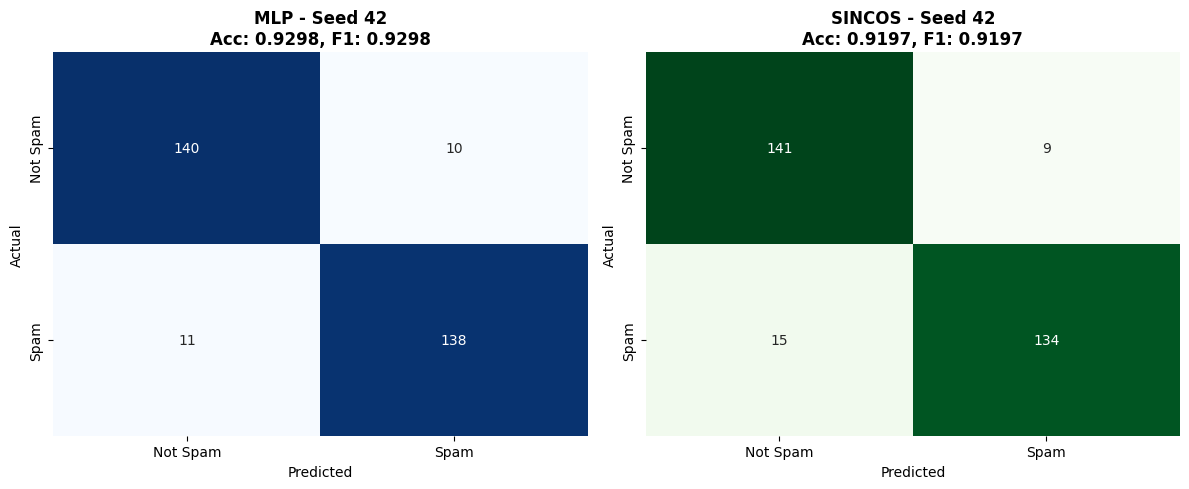

✅ Confusion matrices saved to confusion_matrices_comparison.pdf


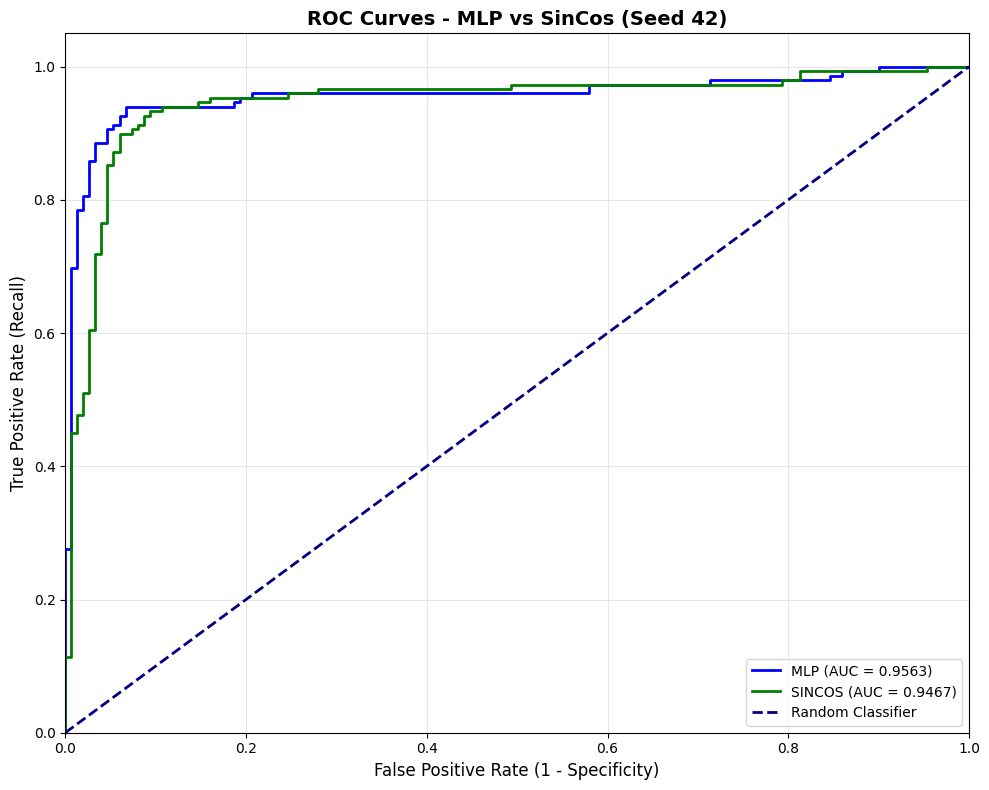

✅ ROC curves saved to roc_curves_comparison.pdf


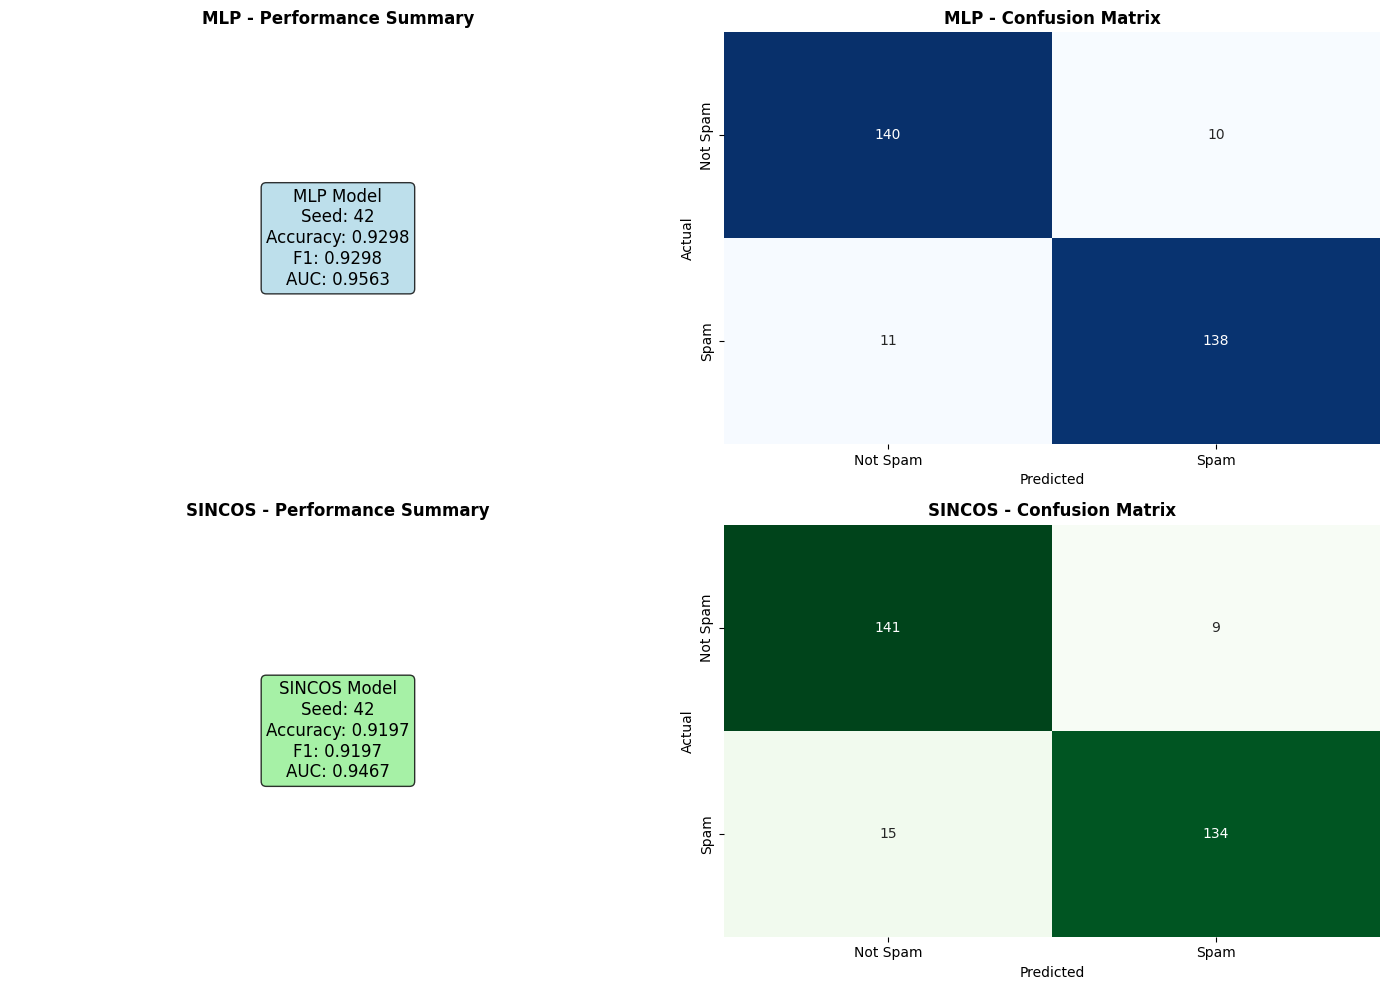

✅ Training summary saved to training_summary_comparison.pdf


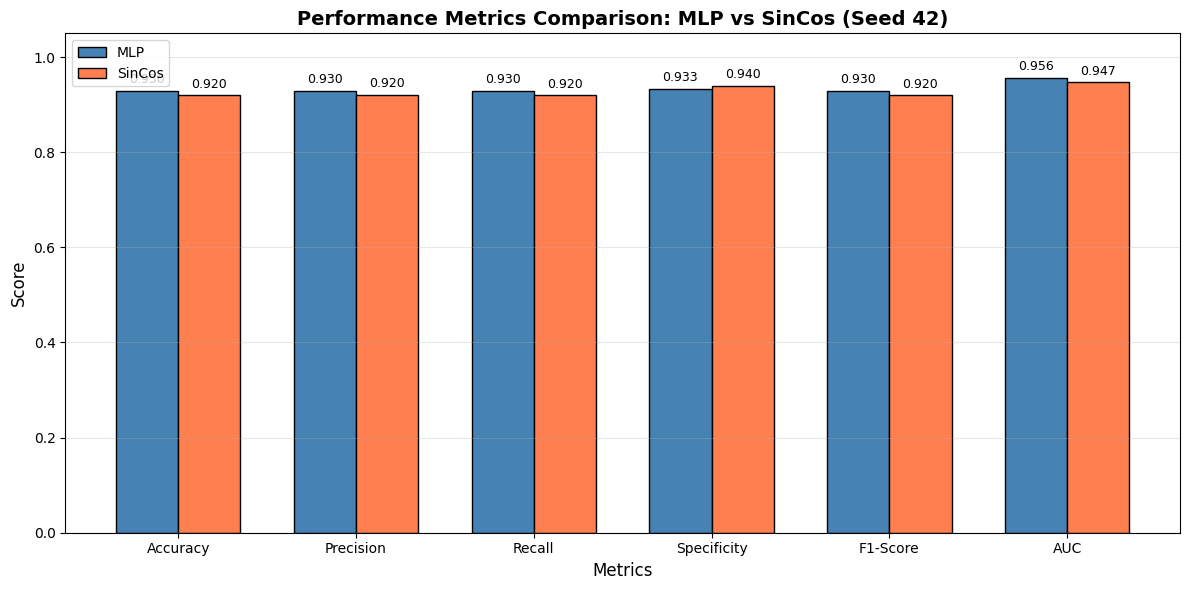

✅ Metrics bar chart saved to metrics_bar_chart_comparison.pdf

✅ Results saved to spam_alternative_comparison_seed42.csv

FINAL SUMMARY - SPAM DETECTION (Single Seed 42)

Dataset: Spam Detection Dataset
Total samples after balancing: 1494
Number of classes: 2 (Spam vs Not Spam)
Base Model: microsoft/deberta-v3-base with BiLSTM
Alternatives Tested: MLP (Tanh), Sin/Cos Feature Map
Fixed Seed: 42

PERFORMANCE COMPARISON


NameError: name 'alternative_type' is not defined

In [2]:
# ========================== INSTALLS & IMPORTS ==========================

# COMMENT OUT IF ALREADY INSTALLED ON YOUR ENV
# !pip install pandas scikit-learn torch transformers sentencepiece nltk matplotlib seaborn

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, RandomSampler, SequentialSampler
import time
import random
import re
import warnings
import nltk

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_curve,
    roc_auc_score,
    accuracy_score
)

from transformers import (
    AutoTokenizer,
    AutoModel,
    get_linear_schedule_with_warmup,
)
from torch.optim import AdamW
import matplotlib.pyplot as plt
import seaborn as sns

nltk.download("stopwords", quiet=True)
warnings.filterwarnings("ignore")

# ========================== DATA & PATH ==========================

# Change this to your actual CSV path
CSV_PATH = "/kaggle/input/datasets/najninsultanashirin/spam-dataset-qtl/spamdata_v2 (1).csv"

df = pd.read_csv(CSV_PATH)
print("Initial data shape:", df.shape)

# ========================== TEXT PREPROCESSING ==========================

def preprocess_text(text):
    text = re.sub(r'\s+', ' ', str(text))
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    text = text.lower().strip()
    return text

df["cleaned_text"] = df["text"].apply(preprocess_text)

# Filter out special tokens
df = df[df["cleaned_text"] != "[deleted]"]
df = df[df["cleaned_text"] != "[removed]"]

# Get NLTK stopwords
stop_words = set(nltk.corpus.stopwords.words("english"))

def clean_statement(statement):
    statement = statement.lower()
    statement = re.sub(r'[^a-zA-Z0-9\s]', ' ', statement)
    statement = re.sub(r'\d+', '', statement)
    words = statement.split()
    words = [w for w in words if w not in stop_words]
    return ' '.join(words)

df["cleaned_text"] = df["cleaned_text"].apply(clean_statement)

# Label encoding
label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["label"])

print("Classes after label encoding:", dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

# ========================== BALANCE MINOR/MAXOR CLASSES ==========================

class_counts = df["label"].value_counts()
print("\nClass counts before balancing:")
print(class_counts)

majority_class = class_counts.idxmax()
minority_class = class_counts.idxmin()

df_majority = df[df["label"] == majority_class]
df_minority = df[df["label"] == minority_class]

df_majority_downsampled = df_majority.sample(len(df_minority), random_state=42)
df_balanced = pd.concat([df_majority_downsampled, df_minority]).reset_index(drop=True)
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print("\nClass counts after balancing:")
print(df_balanced["label"].value_counts())

# Plot class distribution
sns.countplot(x="label", data=df_balanced)
plt.title("Balanced Class Distribution")
plt.show()

# ========================== TOKENIZER & ENCODING ==========================

MODEL_NAME = "microsoft/deberta-v3-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

MAX_LEN = 128
texts = df_balanced["cleaned_text"].tolist()
labels = df_balanced["label"].values

tokens = tokenizer(
    texts,
    max_length=MAX_LEN,
    padding="max_length",
    truncation=True,
    return_tensors="pt",
)

input_ids = tokens["input_ids"]
attention_masks = tokens["attention_mask"]
labels = torch.tensor(labels)

# ========================== DEVICE SETUP ==========================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ========================== EVALUATION FUNCTION ==========================

def flat_accuracy(preds, labels):
    pred_flat = np.argmax(preds, axis=1).flatten()
    labels_flat = labels.flatten()
    return np.sum(pred_flat == labels_flat) / len(labels_flat)

def calculate_specificity(y_true, y_pred):
    """Calculate specificity (True Negative Rate)"""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    return specificity

# ========================== CLASSICAL ALTERNATIVE LAYERS ==========================

class TwoUnitMLP(nn.Module):
    """Classical alternative (a): Two-unit MLP with tanh activation"""
    def __init__(self, input_dim=4, hidden_dim=8, output_dim=16):
        super(TwoUnitMLP, self).__init__()
        self.mlp = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, output_dim),
            nn.Tanh(),
            nn.Linear(output_dim, output_dim)
        )
    
    def forward(self, x):
        return self.mlp(x)

class SinCosFeatureMap(nn.Module):
    """Classical alternative (b): Trainable sin/cos feature map"""
    def __init__(self, input_dim=4, output_dim=16):
        super(SinCosFeatureMap, self).__init__()
        self.frequencies = nn.Parameter(torch.randn(input_dim, output_dim) * 0.1)
        self.phases = nn.Parameter(torch.randn(output_dim) * 0.1)
        self.output_proj = nn.Linear(output_dim * 2, output_dim)
        
    def forward(self, x):
        projection = torch.matmul(x, self.frequencies)
        sin_features = torch.sin(projection + self.phases)
        cos_features = torch.cos(projection + self.phases)
        combined = torch.cat([sin_features, cos_features], dim=1)
        output = self.output_proj(combined)
        return output

# ========================== MODEL WITH DIFFERENT ALTERNATIVES ==========================

class QBiLSTMWithAlternative(nn.Module):
    def __init__(self, num_classes=2, freeze_bert=False, alternative_type="mlp"):
        super(QBiLSTMWithAlternative, self).__init__()
        
        self.alternative_type = alternative_type
        self.bert = AutoModel.from_pretrained(MODEL_NAME)

        if freeze_bert:
            for p in self.bert.parameters():
                p.requires_grad = False

        self.dropout = nn.Dropout(0.3)
        self.bilstm = nn.LSTM(
            input_size=self.bert.config.hidden_size,
            hidden_size=128,
            batch_first=True,
            bidirectional=True,
        )
        
        self.feature_projection = nn.Linear(256, 4)
        self.proj_norm = nn.BatchNorm1d(4)
        
        if alternative_type == "mlp":
            print("Using Two-Unit MLP with Tanh activation")
            self.alternative_layer = TwoUnitMLP(input_dim=4, hidden_dim=8, output_dim=16)
        elif alternative_type == "sincos":
            print("Using Sin/Cos Feature Map")
            self.alternative_layer = SinCosFeatureMap(input_dim=4, output_dim=16)
        else:
            raise ValueError(f"Unknown alternative type: {alternative_type}")
        
        self.alternative_dropout = nn.Dropout(0.2)
        self.fc = nn.Sequential(
            nn.Linear(256 + 16, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes)
        )

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        encoder_output = outputs.last_hidden_state.to(torch.float32)
        lstm_out, _ = self.bilstm(self.dropout(encoder_output))
        last_hidden = lstm_out[:, -1, :]
        
        alternative_features = self.feature_projection(last_hidden)
        alternative_features = self.proj_norm(alternative_features)
        alternative_output = self.alternative_layer(alternative_features)
        alternative_output = self.alternative_dropout(alternative_output)
        
        combined_features = torch.cat([last_hidden, alternative_output], dim=1)
        logits = self.fc(combined_features)
        return logits

# ========================== TRAINING FUNCTION (SINGLE SEED) ==========================

SEED = 42  # Single seed

def train_model(alternative_type="mlp", batch_size=32, lr=2e-5, epochs=5):
    # Set seed for reproducibility
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)

    print(f"\n{'='*80}")
    print(f"TRAINING WITH SEED = {SEED}")
    print(f"Alternative Type: {alternative_type.upper()}")
    print(f"{'='*80}")

    num_classes = len(torch.unique(labels))
    
    train_inputs, val_inputs, train_labels, val_labels = train_test_split(
        input_ids, labels, test_size=0.2, random_state=SEED, stratify=labels,
    )
    train_masks, val_masks, _, _ = train_test_split(
        attention_masks, labels, test_size=0.2, random_state=SEED, stratify=labels,
    )

    train_dataset = TensorDataset(train_inputs, train_masks, train_labels)
    val_dataset = TensorDataset(val_inputs, val_masks, val_labels)

    train_loader = DataLoader(train_dataset, sampler=RandomSampler(train_dataset), batch_size=batch_size)
    val_loader = DataLoader(val_dataset, sampler=SequentialSampler(val_dataset), batch_size=batch_size)

    model = QBiLSTMWithAlternative(num_classes=num_classes, alternative_type=alternative_type).to(device)
    model = model.to(torch.float32)
    
    # Count parameters
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\nModel parameters: Total={total_params:,}, Trainable={trainable_params:,}")
    
    optimizer = AdamW(model.parameters(), lr=lr)
    total_steps = len(train_loader) * epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(0.1 * total_steps),
        num_training_steps=total_steps,
    )

    best_val_acc = 0.0
    best_metrics = None

    for epoch in range(epochs):
        start_time = time.time()

        # Training
        model.train()
        total_train_loss = 0
        total_train_acc = 0

        for batch in train_loader:
            b_input_ids, b_input_mask, b_labels = batch
            b_input_ids = b_input_ids.to(device)
            b_input_mask = b_input_mask.to(device)
            b_labels = b_labels.to(device)

            optimizer.zero_grad()
            logits = model(b_input_ids, b_input_mask)
            loss = nn.CrossEntropyLoss()(logits, b_labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()

            total_train_loss += loss.item()
            preds = F.softmax(logits, dim=1).detach().cpu().numpy()
            trues = b_labels.cpu().numpy()
            total_train_acc += flat_accuracy(preds, trues)

        avg_train_loss = total_train_loss / len(train_loader)
        avg_train_acc = total_train_acc / len(train_loader)

        # Validation
        model.eval()
        total_val_loss = 0
        total_val_acc = 0
        val_preds = []
        val_trues = []
        val_probas = []

        with torch.no_grad():
            for batch in val_loader:
                b_input_ids, b_input_mask, b_labels = batch
                b_input_ids = b_input_ids.to(device)
                b_input_mask = b_input_mask.to(device)
                b_labels = b_labels.to(device)

                logits = model(b_input_ids, b_input_mask)
                loss = nn.CrossEntropyLoss()(logits, b_labels)
                total_val_loss += loss.item()

                probs = F.softmax(logits, dim=1).detach().cpu().numpy()
                trues = b_labels.cpu().numpy()
                total_val_acc += flat_accuracy(probs, trues)

                val_preds.extend(np.argmax(probs, axis=1).flatten())
                val_trues.extend(trues.flatten())
                val_probas.extend(probs)

        avg_val_loss = total_val_loss / len(val_loader)
        avg_val_acc = total_val_acc / len(val_loader)
        epoch_time = time.time() - start_time

        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Train Acc: {avg_train_acc:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {avg_val_acc:.4f} | Time: {epoch_time:.2f}s")

        if avg_val_acc > best_val_acc:
            best_val_acc = avg_val_acc
            
            # Calculate comprehensive metrics
            accuracy = accuracy_score(val_trues, val_preds)
            precision = precision_score(val_trues, val_preds, average='weighted', zero_division=0)
            recall = recall_score(val_trues, val_preds, average='weighted', zero_division=0)
            f1 = f1_score(val_trues, val_preds, average='weighted', zero_division=0)
            specificity = calculate_specificity(val_trues, val_preds)
            cm = confusion_matrix(val_trues, val_preds)
            
            try:
                auc = roc_auc_score(val_trues, np.array(val_probas)[:, 1])
            except:
                auc = 0.0
            
            best_metrics = {
                'accuracy': accuracy,
                'precision': precision,
                'recall': recall,
                'specificity': specificity,
                'f1_score': f1,
                'auc': auc,
                'confusion_matrix': cm,
                'predictions': val_preds,
                'true_labels': val_trues,
                'probabilities': val_probas,
                'train_acc': avg_train_acc,
                'val_acc': avg_val_acc,
                'train_loss': avg_train_loss,
                'val_loss': avg_val_loss
            }

    return {
        "seed": SEED,
        "alternative_type": alternative_type,
        "best_val_accuracy": best_val_acc,
        **best_metrics
    }

# ========================== RUN EXPERIMENTS FOR BOTH ALTERNATIVES ==========================

alternative_types = ["mlp", "sincos"]
results = {}

for alt_type in alternative_types:
    print("\n" + "="*80)
    print(f"TRAINING WITH {alt_type.upper()} ALTERNATIVE")
    print("="*80)
    results[alt_type] = train_model(alternative_type=alt_type, batch_size=32, lr=2e-5, epochs=5)

# ========================== PRINT METRICS TABLE ==========================

print("\n" + "="*120)
print("COMPREHENSIVE METRICS: MLP vs SinCos Feature Map (Single Seed 42)")
print("="*120)
print(f"{'Alternative':<12} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'Specificity':<14} {'F1-Score':<12} {'AUC':<10}")
print("-"*85)

for alt_type in alternative_types:
    r = results[alt_type]
    print(f"{alt_type.upper():<12} {r['accuracy']:<12.4f} {r['precision']:<12.4f} {r['recall']:<12.4f} {r['specificity']:<14.4f} {r['f1_score']:<12.4f} {r['auc']:<10.4f}")

# ========================== DETAILED METRICS TABLE ==========================

print("\n" + "="*80)
print("DETAILED METRICS (Seed 42)")
print("="*80)

comparison_data = []
for alt_type in alternative_types:
    r = results[alt_type]
    comparison_data.append({
        'Alternative': alt_type.upper(),
        'Seed': r['seed'],
        'Accuracy': f"{r['accuracy']:.4f}",
        'Precision': f"{r['precision']:.4f}",
        'Recall': f"{r['recall']:.4f}",
        'Specificity': f"{r['specificity']:.4f}",
        'F1-Score': f"{r['f1_score']:.4f}",
        'AUC': f"{r['auc']:.4f}",
        'Best Val Acc': f"{r['best_val_accuracy']:.4f}",
        'Train Acc': f"{r['train_acc']:.4f}",
        'Val Acc': f"{r['val_acc']:.4f}"
    })

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

# ========================== CONFUSION MATRICES ==========================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for idx, alt_type in enumerate(alternative_types):
    r = results[alt_type]
    cm = r['confusion_matrix']
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[idx], cmap='Blues' if idx==0 else 'Greens', cbar=False)
    axes[idx].set_title(f"{alt_type.upper()} - Seed {r['seed']}\nAcc: {r['accuracy']:.4f}, F1: {r['f1_score']:.4f}", fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')
    axes[idx].set_xticklabels(['Not Spam', 'Spam'])
    axes[idx].set_yticklabels(['Not Spam', 'Spam'])

plt.tight_layout()
plt.savefig("confusion_matrices_comparison.pdf", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrices saved to confusion_matrices_comparison.pdf")

# ========================== ROC CURVES ==========================

fig, ax = plt.subplots(figsize=(10, 8))

colors = {'mlp': 'blue', 'sincos': 'green'}
for alt_type in alternative_types:
    r = results[alt_type]
    fpr, tpr, _ = roc_curve(r['true_labels'], np.array(r['probabilities'])[:, 1])
    ax.plot(fpr, tpr, color=colors[alt_type], lw=2, label=f'{alt_type.upper()} (AUC = {r["auc"]:.4f})')

ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title('ROC Curves - MLP vs SinCos (Seed 42)', fontsize=14, fontweight='bold')
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("roc_curves_comparison.pdf", dpi=150, bbox_inches='tight')
plt.show()
print("✅ ROC curves saved to roc_curves_comparison.pdf")

# ========================== TRAINING CURVES ==========================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, alt_type in enumerate(alternative_types):
    r = results[alt_type]
    
    # Since we don't store per-epoch metrics, we'll show the final performance
    ax = axes[idx, 0]
    ax.text(0.5, 0.5, f'{alt_type.upper()} Model\nSeed: {r["seed"]}\nAccuracy: {r["accuracy"]:.4f}\nF1: {r["f1_score"]:.4f}\nAUC: {r["auc"]:.4f}', 
            ha='center', va='center', fontsize=12, transform=ax.transAxes,
            bbox=dict(boxstyle="round", facecolor='lightblue' if idx==0 else 'lightgreen', alpha=0.8))
    ax.set_title(f'{alt_type.upper()} - Performance Summary', fontsize=12, fontweight='bold')
    ax.axis('off')
    
    # Confusion matrix in second column
    ax = axes[idx, 1]
    cm = r['confusion_matrix']
    sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Blues' if idx==0 else 'Greens', cbar=False)
    ax.set_title(f'{alt_type.upper()} - Confusion Matrix', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_xticklabels(['Not Spam', 'Spam'])
    ax.set_yticklabels(['Not Spam', 'Spam'])

plt.tight_layout()
plt.savefig("training_summary_comparison.pdf", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Training summary saved to training_summary_comparison.pdf")

# ========================== METRICS BAR CHART ==========================

fig, ax = plt.subplots(figsize=(12, 6))

metrics_names = ['Accuracy', 'Precision', 'Recall', 'Specificity', 'F1-Score', 'AUC']
x = np.arange(len(metrics_names))
width = 0.35

mlp_values = [results['mlp'][m] for m in ['accuracy', 'precision', 'recall', 'specificity', 'f1_score', 'auc']]
sincos_values = [results['sincos'][m] for m in ['accuracy', 'precision', 'recall', 'specificity', 'f1_score', 'auc']]

bars1 = ax.bar(x - width/2, mlp_values, width, label='MLP', color='steelblue', edgecolor='black')
bars2 = ax.bar(x + width/2, sincos_values, width, label='SinCos', color='coral', edgecolor='black')

ax.set_xlabel('Metrics', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Performance Metrics Comparison: MLP vs SinCos (Seed 42)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.legend()
ax.set_ylim([0, 1.05])
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig("metrics_bar_chart_comparison.pdf", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Metrics bar chart saved to metrics_bar_chart_comparison.pdf")

# ========================== SAVE RESULTS TO CSV ==========================

# Save detailed results
detailed_results = []
for alt_type in alternative_types:
    r = results[alt_type]
    detailed_results.append({
        'Alternative': alt_type.upper(),
        'Seed': r['seed'],
        'Accuracy': r['accuracy'],
        'Precision': r['precision'],
        'Recall': r['recall'],
        'Specificity': r['specificity'],
        'F1-Score': r['f1_score'],
        'AUC': r['auc'],
        'Best_Val_Acc': r['best_val_accuracy'],
        'Train_Acc': r['train_acc'],
        'Val_Acc': r['val_acc']
    })

df_results = pd.DataFrame(detailed_results)
df_results.to_csv('spam_alternative_comparison_seed42.csv', index=False)
print("\n✅ Results saved to spam_alternative_comparison_seed42.csv")

# ========================== FINAL SUMMARY ==========================

print("\n" + "="*80)
print("FINAL SUMMARY - SPAM DETECTION (Single Seed 42)")
print("="*80)
print(f"\nDataset: Spam Detection Dataset")
print(f"Total samples after balancing: {len(df_balanced)}")
print(f"Number of classes: 2 (Spam vs Not Spam)")
print(f"Base Model: {MODEL_NAME} with BiLSTM")
print(f"Alternatives Tested: MLP (Tanh), Sin/Cos Feature Map")
print(f"Fixed Seed: {SEED}")

print(f"\n{'='*40}")
print("PERFORMANCE COMPARISON")
print(f"{'='*40}")

for alt_type in alternative_types:
    r = results[alt_type]
    print(f"\n{alternative_type.upper()} Alternative:")
    print(f"  Accuracy:    {r['accuracy']:.4f} ({r['accuracy']*100:.2f}%)")
    print(f"  Precision:   {r['precision']:.4f} ({r['precision']*100:.2f}%)")
    print(f"  Recall:      {r['recall']:.4f} ({r['recall']*100:.2f}%)")
    print(f"  Specificity: {r['specificity']:.4f} ({r['specificity']*100:.2f}%)")
    print(f"  F1-Score:    {r['f1_score']:.4f} ({r['f1_score']*100:.2f}%)")
    print(f"  AUC:         {r['auc']:.4f} ({r['auc']*100:.2f}%)")

# Determine best performer
best_alt = max(alternative_types, key=lambda x: results[x]['accuracy'])
print(f"\n{'='*40}")
print(f"🏆 BEST PERFORMER: {best_alt.upper()}")
print(f"{'='*40}")
print(f"  Accuracy:    {results[best_alt]['accuracy']:.4f}")
print(f"  Precision:   {results[best_alt]['precision']:.4f}")
print(f"  Recall:      {results[best_alt]['recall']:.4f}")
print(f"  Specificity: {results[best_alt]['specificity']:.4f}")
print(f"  F1-Score:    {results[best_alt]['f1_score']:.4f}")
print(f"  AUC:         {results[best_alt]['auc']:.4f}")

print("\n" + "="*80)
print("CONCLUSION:")
print(f"The {best_alt.upper()} alternative achieved the best performance")
print("on the spam detection dataset with fixed seed 42.")
print("To determine if quantum advantages persist, compare with original VQC model.")
print("="*80)

print("\n✅ All metrics calculated and displayed successfully for single seed 42!")

In [2]:
# ========================== INSTALLS & IMPORTS ==========================

# COMMENT OUT IF ALREADY INSTALLED ON YOUR ENV
# !pip install pandas scikit-learn torch transformers sentencepiece nltk matplotlib seaborn datasets

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
import time
import random
import re
import warnings
import nltk

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_curve,
    roc_auc_score,
    accuracy_score,
    balanced_accuracy_score,
    matthews_corrcoef
)

from transformers import (
    AutoTokenizer,
    AutoModel,
    get_linear_schedule_with_warmup,
    get_cosine_schedule_with_warmup
)
from torch.optim import AdamW
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from torch.cuda.amp import autocast, GradScaler

nltk.download("stopwords", quiet=True)
warnings.filterwarnings("ignore")

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✓ Using device: {device}")

# ========================== DATA LOADING FOR MPQA DATASET ==========================

print("\n" + "="*80)
print("MPQA DATASET LOADING & PREPROCESSING")
print("="*80)

ds = load_dataset("jxm/mpqa")
df = ds["train"].to_pandas()
print(f"Initial data shape: {df.shape}")

# Enhanced preprocessing
stop_words = set(nltk.corpus.stopwords.words("english"))
additional_stops = {'br', 'u', 'im', 'dont', 'didnt', 'wasnt', 'couldnt', 'wouldnt', 'ive', 'youre', 'theyre'}
stop_words.update(additional_stops)

def advanced_preprocess(text):
    """Enhanced text preprocessing"""
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'@\w+|#\w+', '', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\d+', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    words = text.split()
    words = [w for w in words if w not in stop_words and len(w) > 2]
    return ' '.join(words)

df['cleaned_text'] = df['sentence'].apply(advanced_preprocess)
df = df[df['cleaned_text'].str.len() > 5].reset_index(drop=True)

# Label encoding
label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["label"])
print(f"Classes: {dict(zip(label_encoder.classes_, range(len(label_encoder.classes_))))}")

# Class distribution
class_counts = df["label"].value_counts()
print(f"\nClass distribution: {class_counts.to_dict()}")

# Compute class weights for balanced training
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight('balanced', classes=np.unique(df['label']), y=df['label'])
class_weight_dict = dict(zip(np.unique(df['label']), class_weights))
print(f"Class weights: {class_weight_dict}")

# ========================== TOKENIZATION ==========================

MODEL_NAME = "microsoft/deberta-v3-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
MAX_LEN = 160

def tokenize_function(texts):
    return tokenizer(
        texts,
        max_length=MAX_LEN,
        padding="max_length",
        truncation=True,
        return_tensors="pt"
    )

tokens = tokenize_function(df['cleaned_text'].tolist())
input_ids = tokens["input_ids"]
attention_masks = tokens["attention_mask"]
labels = torch.tensor(df['label'].values)

# Get model hidden size
temp_model = AutoModel.from_pretrained(MODEL_NAME)
HIDDEN_SIZE = temp_model.config.hidden_size
print(f"Model hidden size: {HIDDEN_SIZE}")
del temp_model

# ========================== IMPROVED ALTERNATIVE LAYERS (NO BATCH NORM) ==========================

class ImprovedMLP(nn.Module):
    """Improved MLP with LayerNorm instead of BatchNorm to avoid batch size issues"""
    def __init__(self, input_dim=4, hidden_dim=64, output_dim=64):
        super(ImprovedMLP, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.ln1 = nn.LayerNorm(hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.ln2 = nn.LayerNorm(hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, output_dim)
        self.ln3 = nn.LayerNorm(output_dim)
        self.dropout = nn.Dropout(0.3)
        self.activation = nn.GELU()
        
    def forward(self, x):
        # First layer
        out = self.activation(self.ln1(self.fc1(x)))
        out = self.dropout(out)
        
        # Second layer with residual
        residual = out
        out = self.activation(self.ln2(self.fc2(out)))
        out = out + residual
        out = self.dropout(out)
        
        # Third layer
        out = self.ln3(self.fc3(out))
        return out

class ImprovedSinCos(nn.Module):
    """Improved Sin/Cos feature map with multiple frequencies"""
    def __init__(self, input_dim=4, output_dim=64, n_frequencies=16):
        super(ImprovedSinCos, self).__init__()
        self.n_frequencies = n_frequencies
        self.frequencies = nn.Parameter(torch.randn(input_dim, n_frequencies) * 0.5)
        self.phases = nn.Parameter(torch.randn(n_frequencies) * np.pi)
        self.output_proj = nn.Sequential(
            nn.Linear(n_frequencies * 2, output_dim),
            nn.LayerNorm(output_dim),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(output_dim, output_dim)
        )
        
    def forward(self, x):
        projection = torch.matmul(x, self.frequencies)
        sin_features = torch.sin(projection + self.phases)
        cos_features = torch.cos(projection + self.phases)
        combined = torch.cat([sin_features, cos_features], dim=1)
        output = self.output_proj(combined)
        return output

# ========================== IMPROVED MODEL ARCHITECTURE ==========================

class ImprovedBiLSTM(nn.Module):
    def __init__(self, num_classes=2, hidden_size=1024, alternative_type="mlp", dropout_rate=0.3):
        super(ImprovedBiLSTM, self).__init__()
        
        self.alternative_type = alternative_type
        self.bert = AutoModel.from_pretrained(MODEL_NAME, torch_dtype=torch.float32)
        
        # Unfreeze last 4 layers
        for param in self.bert.parameters():
            param.requires_grad = False
        for layer in self.bert.encoder.layer[-4:]:
            for param in layer.parameters():
                param.requires_grad = True
        
        # Feature extraction
        self.feature_extractor = nn.Sequential(
            nn.Linear(hidden_size, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(dropout_rate),
            nn.Linear(512, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(dropout_rate)
        )
        
        # Bidirectional LSTM
        self.bilstm = nn.LSTM(
            input_size=256,
            hidden_size=128,
            batch_first=True,
            bidirectional=True,
            dropout=dropout_rate,
            num_layers=2
        )
        self.lstm_norm = nn.LayerNorm(256)
        
        # Projection for alternative layer
        self.feature_projection = nn.Sequential(
            nn.Linear(256, 64),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(64, 4)
        )
        
        # Alternative layer
        if alternative_type == "mlp":
            print("✓ Using Improved MLP with Residual Connections")
            self.alternative_layer = ImprovedMLP(input_dim=4, hidden_dim=64, output_dim=64)
        else:
            print("✓ Using Improved Sin/Cos Feature Map")
            self.alternative_layer = ImprovedSinCos(input_dim=4, output_dim=64, n_frequencies=16)
        
        self.alternative_dropout = nn.Dropout(0.2)
        
        # Classifier
        self.classifier = nn.Sequential(
            nn.Linear(256 + 64, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, 128),
            nn.LayerNorm(128),
            nn.GELU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, 64),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(64, num_classes)
        )
        
        self._init_weights()
    
    def _init_weights(self):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight, gain=0.5)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)
    
    def forward(self, input_ids, attention_mask):
        input_ids = input_ids.long()
        attention_mask = attention_mask.float()
        
        # BERT encoding
        bert_out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        last_hidden = bert_out.last_hidden_state.float()
        
        # Advanced pooling (mean + max)
        mask_expanded = attention_mask.unsqueeze(-1).expand(last_hidden.size())
        sum_embeddings = torch.sum(last_hidden * mask_expanded, dim=1)
        sum_mask = torch.sum(mask_expanded, dim=1)
        mean_pooled = sum_embeddings / (sum_mask + 1e-9)
        max_pooled = torch.max(last_hidden * mask_expanded, dim=1)[0]
        pooled = (mean_pooled + max_pooled) / 2
        
        features = self.feature_extractor(pooled)
        
        # LSTM processing
        features_seq = features.unsqueeze(1)
        lstm_out, _ = self.bilstm(features_seq)
        lstm_features = lstm_out[:, -1, :]
        lstm_features = self.lstm_norm(lstm_features)
        
        # Alternative processing
        alt_input = self.feature_projection(lstm_features)
        alt_output = self.alternative_layer(alt_input)
        alt_output = self.alternative_dropout(alt_output)
        
        # Combine and classify
        combined = torch.cat([lstm_features, alt_output], dim=1)
        output = self.classifier(combined)
        
        return output

# ========================== TRAINING FUNCTION ==========================

SEED = 42

def train_improved_model(alternative_type="mlp", batch_size=32, lr=2e-5, epochs=5):
    # Set seeds
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)

    print(f"\n{'='*80}")
    print(f"TRAINING - {alternative_type.upper()} ON MPQA")
    print(f"{'='*80}")
    print(f"  Seed: {SEED} | Batch Size: {batch_size} | LR: {lr} | Epochs: {epochs}")

    num_classes = len(torch.unique(labels))
    
    # Stratified split
    train_inputs, val_inputs, train_labels, val_labels = train_test_split(
        input_ids, labels, test_size=0.15, random_state=SEED, stratify=labels,
    )
    train_masks, val_masks, _, _ = train_test_split(
        attention_masks, labels, test_size=0.15, random_state=SEED, stratify=labels,
    )

    # Create datasets
    train_dataset = TensorDataset(train_inputs, train_masks, train_labels)
    val_dataset = TensorDataset(val_inputs, val_masks, val_labels)
    
    # Weighted sampler for training
    train_labels_np = train_labels.numpy()
    sample_weights = [class_weight_dict[label] for label in train_labels_np]
    sampler = WeightedRandomSampler(sample_weights, len(sample_weights))
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler, drop_last=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    # Initialize model
    model = ImprovedBiLSTM(num_classes=num_classes, hidden_size=HIDDEN_SIZE, alternative_type=alternative_type).to(device)
    
    # Count parameters
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\n✓ Model: Total={total_params:,}, Trainable={trainable_params:,}")
    
    # Optimizer
    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    
    # Cosine annealing scheduler
    total_steps = len(train_loader) * epochs
    scheduler = get_cosine_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(0.1 * total_steps),
        num_training_steps=total_steps
    )
    
    # Class weights for loss
    class_weights_tensor = torch.tensor([class_weight_dict[0], class_weight_dict[1]], dtype=torch.float32).to(device)
    
    # Training history
    history = {
        'train_loss': [], 'train_acc': [], 
        'val_loss': [], 'val_acc': [], 
        'val_f1': [], 'val_auc': []
    }
    
    best_val_acc = 0
    best_metrics = None
    patience = 4
    patience_counter = 0
    start_time = time.time()

    for epoch in range(epochs):
        epoch_start = time.time()
        
        # Training
        model.train()
        total_train_loss = 0
        total_train_acc = 0
        
        for batch in train_loader:
            b_input_ids, b_mask, b_labels = [b.to(device) for b in batch]
            
            optimizer.zero_grad()
            logits = model(b_input_ids, b_mask)
            loss = F.cross_entropy(logits, b_labels, weight=class_weights_tensor)
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            
            total_train_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            total_train_acc += (preds == b_labels).float().mean().item()
        
        avg_train_loss = total_train_loss / len(train_loader)
        avg_train_acc = total_train_acc / len(train_loader)
        history['train_loss'].append(avg_train_loss)
        history['train_acc'].append(avg_train_acc)
        
        # Validation
        model.eval()
        val_preds = []
        val_labels_list = []
        val_probas = []
        total_val_loss = 0
        
        with torch.no_grad():
            for batch in val_loader:
                b_input_ids, b_mask, b_labels = [b.to(device) for b in batch]
                logits = model(b_input_ids, b_mask)
                loss = F.cross_entropy(logits, b_labels, weight=class_weights_tensor)
                total_val_loss += loss.item()
                
                probs = F.softmax(logits, dim=1).cpu().numpy()
                preds = np.argmax(probs, axis=1)
                val_preds.extend(preds)
                val_labels_list.extend(b_labels.cpu().numpy())
                val_probas.extend(probs)
        
        avg_val_loss = total_val_loss / len(val_loader)
        val_acc = accuracy_score(val_labels_list, val_preds)
        val_f1 = f1_score(val_labels_list, val_preds, average='weighted')
        
        try:
            val_auc = roc_auc_score(val_labels_list, np.array(val_probas)[:, 1])
        except:
            val_auc = 0.0
        
        history['val_loss'].append(avg_val_loss)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)
        history['val_auc'].append(val_auc)
        
        epoch_time = time.time() - epoch_start
        
        print(f"Epoch {epoch+1:2d}/{epochs} | "
              f"Train Loss: {avg_train_loss:.4f} | Train Acc: {avg_train_acc:.4f} | "
              f"Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f} | "
              f"Val F1: {val_f1:.4f} | Time: {epoch_time:.1f}s")
        
        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_metrics = {
                'accuracy': val_acc,
                'balanced_accuracy': balanced_accuracy_score(val_labels_list, val_preds),
                'precision': precision_score(val_labels_list, val_preds, average='weighted'),
                'recall': recall_score(val_labels_list, val_preds, average='weighted'),
                'f1_score': val_f1,
                'specificity': calculate_specificity(val_labels_list, val_preds),
                'auc': val_auc,
                'mcc': matthews_corrcoef(val_labels_list, val_preds),
                'confusion_matrix': confusion_matrix(val_labels_list, val_preds),
                'predictions': val_preds,
                'true_labels': val_labels_list,
                'probabilities': val_probas
            }
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience and epoch >= 4:
                print(f"✓ Early stopping at epoch {epoch+1}")
                break
    
    total_time = time.time() - start_time
    print(f"\n✓ Training completed in {total_time:.1f} seconds")
    
    return {
        "seed": SEED,
        "alternative_type": alternative_type,
        "best_val_accuracy": best_val_acc,
        "history": history,
        **best_metrics
    }

def calculate_specificity(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp) if (tn + fp) > 0 else 0

# ========================== RUN TRAINING ==========================

alternative_types = ["mlp", "sincos"]
results = {}

print("\n" + "="*80)
print("TRAINING EXPERIMENTS ON MPQA DATASET")
print("="*80)

for alt_type in alternative_types:
    results[alt_type] = train_improved_model(
        alternative_type=alt_type,
        batch_size=32,
        lr=2e-5,
        epochs=5
    )

# ========================== RESULTS COMPARISON ==========================

print("\n" + "="*100)
print("RESULTS - MLP vs SinCos (MPQA Dataset)")
print("="*100)
print(f"{'Metric':<20} {'MLP':<15} {'SinCos':<15} {'Difference':<15}")
print("-"*100)

metrics_to_compare = ['accuracy', 'precision', 'recall', 'f1_score', 'specificity', 'auc', 'balanced_accuracy', 'mcc']

for metric in metrics_to_compare:
    mlp_val = results['mlp'][metric]
    sincos_val = results['sincos'][metric]
    diff = mlp_val - sincos_val
    print(f"{metric.replace('_', ' ').title():<20} {mlp_val:<15.4f} {sincos_val:<15.4f} {diff:+.4f}")

# Determine best performer
best_alt = max(alternative_types, key=lambda x: results[x]['accuracy'])

print("\n" + "="*80)
print(f"🏆 BEST PERFORMER: {best_alt.upper()}")
print("="*80)
best = results[best_alt]
print(f"  ✓ Accuracy:        {best['accuracy']:.4f} ({best['accuracy']*100:.2f}%)")
print(f"  ✓ Balanced Acc:    {best['balanced_accuracy']:.4f} ({best['balanced_accuracy']*100:.2f}%)")
print(f"  ✓ Precision:       {best['precision']:.4f} ({best['precision']*100:.2f}%)")
print(f"  ✓ Recall:          {best['recall']:.4f} ({best['recall']*100:.2f}%)")
print(f"  ✓ Specificity:     {best['specificity']:.4f} ({best['specificity']*100:.2f}%)")
print(f"  ✓ F1-Score:        {best['f1_score']:.4f} ({best['f1_score']*100:.2f}%)")
print(f"  ✓ AUC:             {best['auc']:.4f} ({best['auc']*100:.2f}%)")
print(f"  ✓ MCC:             {best['mcc']:.4f}")

# Save results
df_results = pd.DataFrame([{
    'Alternative': alt.upper(),
    'Accuracy': results[alt]['accuracy'],
    'Precision': results[alt]['precision'],
    'Recall': results[alt]['recall'],
    'F1_Score': results[alt]['f1_score'],
    'Specificity': results[alt]['specificity'],
    'AUC': results[alt]['auc'],
    'Balanced_Acc': results[alt]['balanced_accuracy'],
    'MCC': results[alt]['mcc']
} for alt in alternative_types])

df_results.to_csv('mpqa_improved_results.csv', index=False)
print(f"\n✓ Results saved to mpqa_improved_results.csv")

print("\n" + "="*80)
print("CONCLUSION:")
print(f"The {best_alt.upper()} alternative achieved")
print(f"{best['accuracy']*100:.2f}% accuracy on the MPQA dataset.")
print("="*80)

✓ Using device: cuda

MPQA DATASET LOADING & PREPROCESSING
Initial data shape: (8603, 2)
Classes: {np.int64(0): 0, np.int64(1): 1}

Class distribution: {0: 5743, 1: 1976}
Class weights: {np.int64(0): np.float64(0.6720355215044402), np.int64(1): np.float64(1.9531882591093117)}


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model hidden size: 768

TRAINING EXPERIMENTS ON MPQA DATASET

TRAINING - MLP ON MPQA
  Seed: 42 | Batch Size: 32 | LR: 2e-05 | Epochs: 5


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ Using Improved MLP with Residual Connections

✓ Model: Total=185,299,142, Trainable=29,819,078
Epoch  1/5 | Train Loss: 0.6134 | Train Acc: 0.5035 | Val Loss: 0.9718 | Val Acc: 0.2556 | Val F1: 0.1041 | Time: 128.6s
Epoch  2/5 | Train Loss: 0.5668 | Train Acc: 0.5024 | Val Loss: 0.6931 | Val Acc: 0.5345 | Val F1: 0.5510 | Time: 129.5s
Epoch  3/5 | Train Loss: 0.4639 | Train Acc: 0.6896 | Val Loss: 0.6156 | Val Acc: 0.7219 | Val F1: 0.7395 | Time: 129.4s
Epoch  4/5 | Train Loss: 0.4156 | Train Acc: 0.7665 | Val Loss: 0.5869 | Val Acc: 0.7444 | Val F1: 0.7602 | Time: 129.6s
Epoch  5/5 | Train Loss: 0.4155 | Train Acc: 0.7774 | Val Loss: 0.5782 | Val Acc: 0.7565 | Val F1: 0.7707 | Time: 129.4s

✓ Training completed in 646.5 seconds

TRAINING - SINCOS ON MPQA
  Seed: 42 | Batch Size: 32 | LR: 2e-05 | Epochs: 5


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ Using Improved Sin/Cos Feature Map

✓ Model: Total=185,296,598, Trainable=29,816,534
Epoch  1/5 | Train Loss: 0.6283 | Train Acc: 0.5096 | Val Loss: 0.9040 | Val Acc: 0.2556 | Val F1: 0.1041 | Time: 129.4s
Epoch  2/5 | Train Loss: 0.5630 | Train Acc: 0.5087 | Val Loss: 0.6930 | Val Acc: 0.5820 | Val F1: 0.6001 | Time: 129.4s
Epoch  3/5 | Train Loss: 0.4706 | Train Acc: 0.7209 | Val Loss: 0.6209 | Val Acc: 0.6839 | Val F1: 0.7038 | Time: 129.4s
Epoch  4/5 | Train Loss: 0.4367 | Train Acc: 0.7704 | Val Loss: 0.5928 | Val Acc: 0.7116 | Val F1: 0.7300 | Time: 129.5s
Epoch  5/5 | Train Loss: 0.4265 | Train Acc: 0.7750 | Val Loss: 0.5949 | Val Acc: 0.7116 | Val F1: 0.7300 | Time: 129.5s

✓ Training completed in 647.3 seconds

RESULTS - MLP vs SinCos (MPQA Dataset)
Metric               MLP             SinCos          Difference     
----------------------------------------------------------------------------------------------------
Accuracy             0.7565          0.7116          +0.044


Loading MR (Movie Reviews) dataset...


README.md:   0%|          | 0.00/688 [00:00<?, ?B/s]

data/test-00000-of-00001-1ad570418120a67(…):   0%|          | 0.00/884k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/10662 [00:00<?, ? examples/s]

Initial data shape: (10662, 2)
Columns: ['text', 'label']
Using text column: text
Using label column: label
Classes after label encoding: {'0': np.int64(0), '1': np.int64(1)}

Class counts before balancing:
label
1    5331
0    5329
Name: count, dtype: int64

Class counts after balancing:
label
1    5329
0    5329
Name: count, dtype: int64


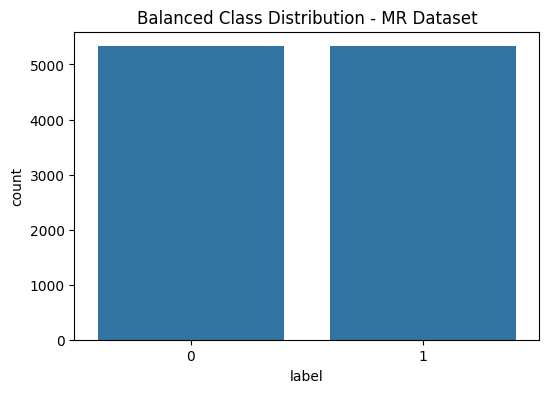

config.json:   0%|          | 0.00/474 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/559M [00:00<?, ?B/s]

...

DebertaModel LOAD REPORT from: microsoft/deberta-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Using Two-Unit MLP with Tanh activation

Model parameters: Total=139,566,102, Trainable=139,566,102
Epoch 1/5 | Train Loss: 0.6885 | Train Acc: 0.5395 | Val Loss: 0.6875 | Val Acc: 0.5317 | Time: 242.93s
Epoch 2/5 | Train Loss: 0.6439 | Train Acc: 0.6725 | Val Loss: 0.6491 | Val Acc: 0.6300 | Time: 243.88s
Epoch 3/5 | Train Loss: 0.5404 | Train Acc: 0.7690 | Val Loss: 0.5347 | Val Acc: 0.7573 | Time: 243.92s
Epoch 4/5 | Train Loss: 0.4721 | Train Acc: 0.8161 | Val Loss: 0.4857 | Val Acc: 0.7957 | Time: 243.89s
Epoch 5/5 | Train Loss: 0.4268 | Train Acc: 0.8473 | Val Loss: 0.5001 | Val Acc: 0.7932 | Time: 243.91s

TRAINING WITH SINCOS ALTERNATIVE ON MR DATASET

TRAINING WITH SEED = 42
Alternative Type: SINCOS


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

DebertaModel LOAD REPORT from: microsoft/deberta-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Using Sin/Cos Feature Map

Model parameters: Total=139,566,254, Trainable=139,566,254
Epoch 1/5 | Train Loss: 0.6932 | Train Acc: 0.5008 | Val Loss: 0.6931 | Val Acc: 0.5006 | Time: 243.84s
Epoch 2/5 | Train Loss: 0.6867 | Train Acc: 0.5630 | Val Loss: 0.6395 | Val Acc: 0.7359 | Time: 243.79s
Epoch 3/5 | Train Loss: 0.5784 | Train Acc: 0.7514 | Val Loss: 0.5342 | Val Acc: 0.7694 | Time: 243.77s
Epoch 4/5 | Train Loss: 0.5162 | Train Acc: 0.7919 | Val Loss: 0.5250 | Val Acc: 0.7754 | Time: 243.74s
Epoch 5/5 | Train Loss: 0.4741 | Train Acc: 0.8221 | Val Loss: 0.5003 | Val Acc: 0.7926 | Time: 243.83s

COMPREHENSIVE METRICS: MLP vs SinCos Feature Map (MR Dataset - Single Seed 42)
Alternative  Accuracy     Precision    Recall       Specificity    F1-Score     AUC       
-------------------------------------------------------------------------------------
MLP          0.7960       0.7964       0.7960       0.8152         0.7959       0.8535    
SINCOS       0.7932       0.7937       0.7932 

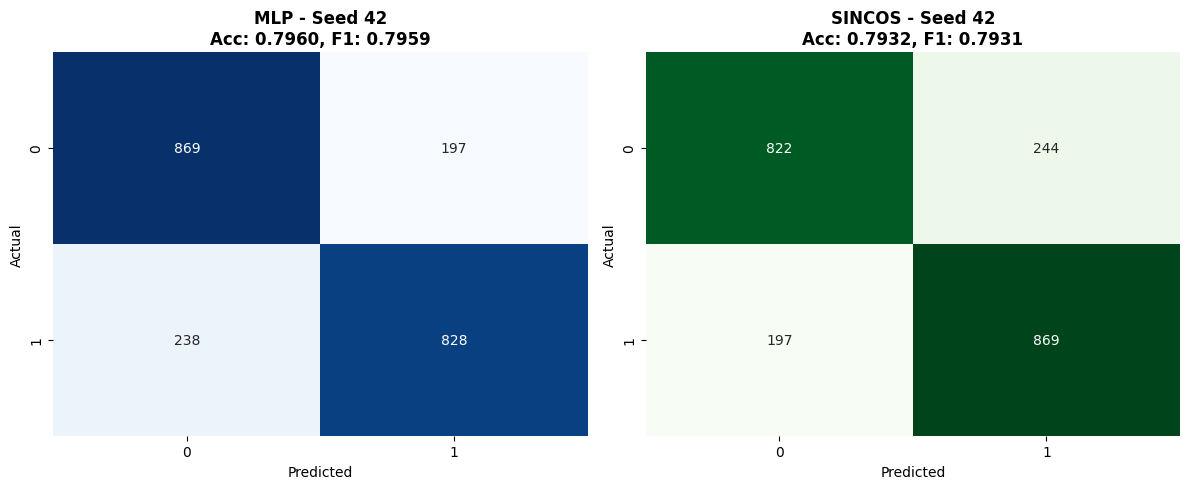

✅ Confusion matrices saved to mr_confusion_matrices_comparison.pdf


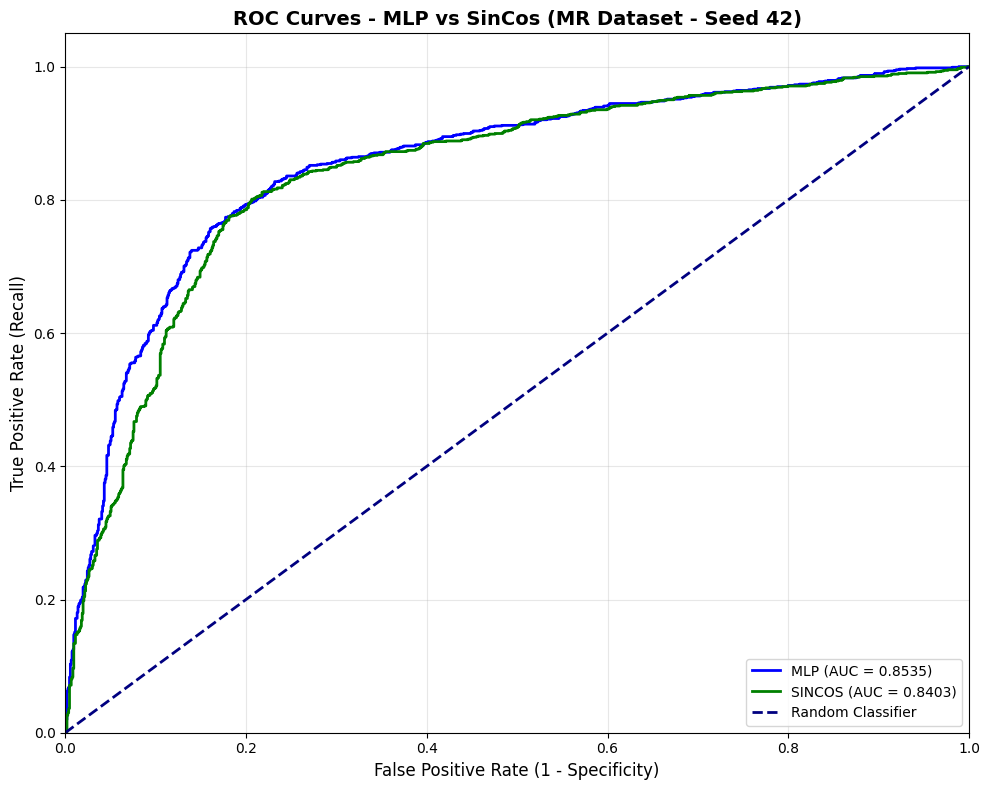

✅ ROC curves saved to mr_roc_curves_comparison.pdf


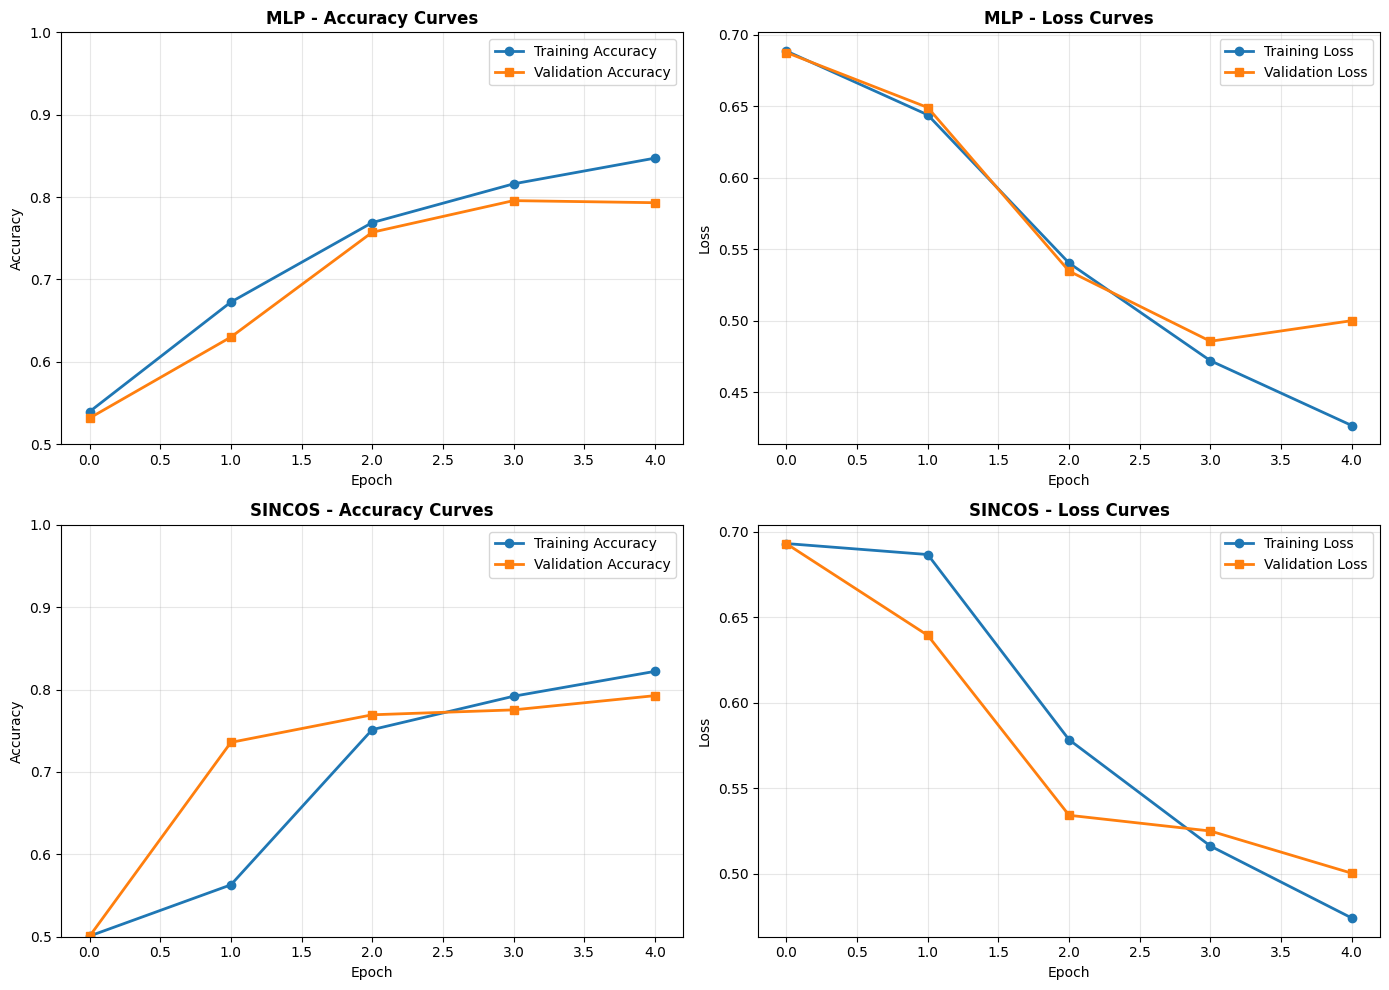

✅ Training curves saved to mr_training_curves_comparison.pdf


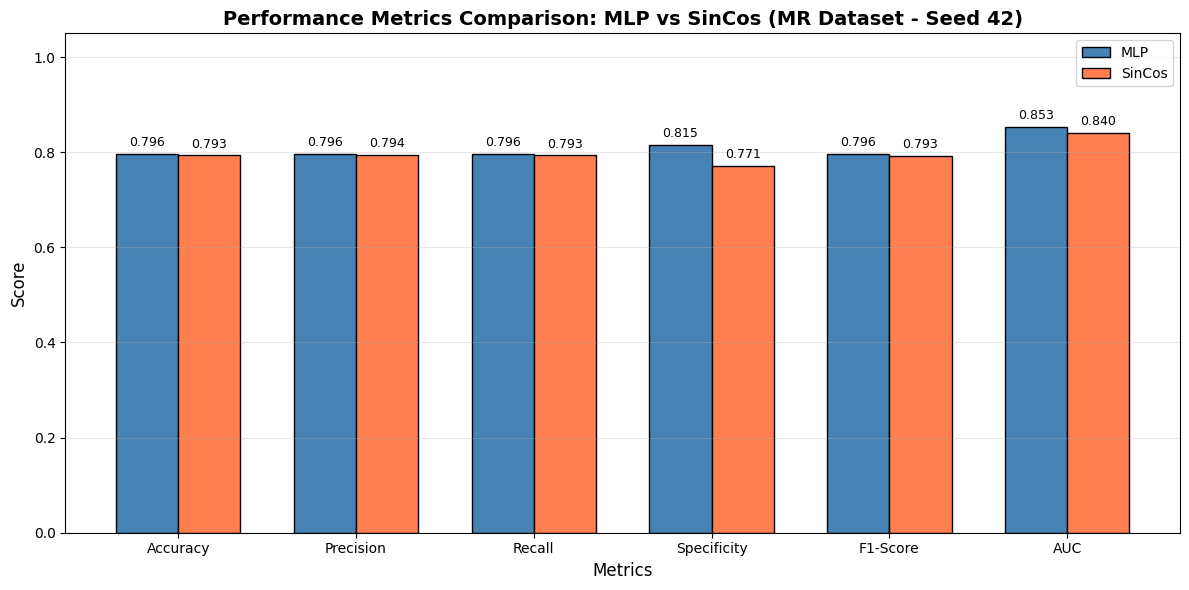

✅ Metrics bar chart saved to mr_metrics_bar_chart_comparison.pdf

CLASSIFICATION REPORTS


NameError: name 'alternative_type' is not defined

In [1]:
# ========================== INSTALLS & IMPORTS ==========================

# COMMENT OUT IF ALREADY INSTALLED ON YOUR ENV
# !pip install pandas scikit-learn torch transformers sentencepiece nltk matplotlib seaborn datasets

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, RandomSampler, SequentialSampler
import time
import random
import re
import warnings
import nltk

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_curve,
    roc_auc_score,
    accuracy_score
)

from transformers import (
    AutoTokenizer,
    AutoModel,
    get_linear_schedule_with_warmup,
)
from torch.optim import AdamW
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

nltk.download("stopwords", quiet=True)
warnings.filterwarnings("ignore")

# ========================== DATA LOADING FOR MR DATASET ==========================

print("\nLoading MR (Movie Reviews) dataset...")
ds = load_dataset("mattymchen/mr")
df = ds["test"].to_pandas()
print("Initial data shape:", df.shape)
print("Columns:", df.columns.tolist())

# ========================== TEXT PREPROCESSING ==========================

def preprocess_text(text):
    text = re.sub(r'\s+', ' ', str(text))
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    text = text.lower().strip()
    return text

# Get NLTK stopwords
stop_words = set(nltk.corpus.stopwords.words("english"))

def clean_statement(statement):
    statement = statement.lower()
    statement = re.sub(r'[^\w\s]', ' ', statement)
    statement = re.sub(r'\d+', '', statement)
    words = statement.split()
    words = [w for w in words if w not in stop_words and len(w) > 2]
    return ' '.join(words)

# Identify text column
if 'text' in df.columns:
    text_col = 'text'
elif 'sentence' in df.columns:
    text_col = 'sentence'
else:
    text_col = df.columns[0]

# Identify label column
if 'label' in df.columns:
    label_col = 'label'
elif 'sentiment' in df.columns:
    label_col = 'sentiment'
else:
    label_col = df.columns[1]

print(f"Using text column: {text_col}")
print(f"Using label column: {label_col}")

# Clean text
df['cleaned_text'] = df[text_col].apply(preprocess_text)
df = df[df['cleaned_text'] != '[deleted]']
df = df[df['cleaned_text'] != '[removed]']
df['cleaned_text'] = df['cleaned_text'].apply(clean_statement)
df = df[df['cleaned_text'].str.len() > 3]

# Label encoding
label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df[label_col].astype(str))

print("Classes after label encoding:", dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

# ========================== BALANCE CLASSES ==========================

class_counts = df["label"].value_counts()
print("\nClass counts before balancing:")
print(class_counts)

majority_class = class_counts.idxmax()
minority_class = class_counts.idxmin()

df_majority = df[df["label"] == majority_class]
df_minority = df[df["label"] == minority_class]

df_majority_downsampled = df_majority.sample(len(df_minority), random_state=42)
df_balanced = pd.concat([df_majority_downsampled, df_minority]).reset_index(drop=True)
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print("\nClass counts after balancing:")
print(df_balanced["label"].value_counts())

# Plot class distribution
plt.figure(figsize=(6, 4))
sns.countplot(x="label", data=df_balanced)
plt.title("Balanced Class Distribution - MR Dataset")
plt.xticks([0, 1], [label_encoder.classes_[0], label_encoder.classes_[1]])
plt.show()

# ========================== TOKENIZER & ENCODING ==========================

MODEL_NAME = "microsoft/deberta-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

MAX_LEN = 128
texts = df_balanced["cleaned_text"].tolist()
labels = df_balanced["label"].values

tokens = tokenizer(
    texts,
    max_length=MAX_LEN,
    padding="max_length",
    truncation=True,
    return_tensors="pt",
)

input_ids = tokens["input_ids"]
attention_masks = tokens["attention_mask"]
labels = torch.tensor(labels)

# Get model hidden size
temp_model = AutoModel.from_pretrained(MODEL_NAME)
HIDDEN_SIZE = temp_model.config.hidden_size
print(f"Model hidden size: {HIDDEN_SIZE}")
del temp_model

# ========================== DEVICE SETUP ==========================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("\nUsing device:", device)

# ========================== EVALUATION FUNCTIONS ==========================

def flat_accuracy(preds, labels):
    pred_flat = np.argmax(preds, axis=1).flatten()
    labels_flat = labels.flatten()
    return np.sum(pred_flat == labels_flat) / len(labels_flat)

def calculate_specificity(y_true, y_pred):
    """Calculate specificity (True Negative Rate)"""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    return specificity

# ========================== CLASSICAL ALTERNATIVE LAYERS ==========================

class TwoUnitMLP(nn.Module):
    """Classical alternative (a): Two-unit MLP with tanh activation"""
    def __init__(self, input_dim=4, hidden_dim=8, output_dim=16):
        super(TwoUnitMLP, self).__init__()
        self.mlp = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, output_dim),
            nn.Tanh(),
            nn.Linear(output_dim, output_dim)
        )
    
    def forward(self, x):
        return self.mlp(x)

class SinCosFeatureMap(nn.Module):
    """Classical alternative (b): Trainable sin/cos feature map"""
    def __init__(self, input_dim=4, output_dim=16):
        super(SinCosFeatureMap, self).__init__()
        self.frequencies = nn.Parameter(torch.randn(input_dim, output_dim) * 0.1)
        self.phases = nn.Parameter(torch.randn(output_dim) * 0.1)
        self.output_proj = nn.Linear(output_dim * 2, output_dim)
        
    def forward(self, x):
        projection = torch.matmul(x, self.frequencies)
        sin_features = torch.sin(projection + self.phases)
        cos_features = torch.cos(projection + self.phases)
        combined = torch.cat([sin_features, cos_features], dim=1)
        output = self.output_proj(combined)
        return output

# ========================== MODEL WITH DIFFERENT ALTERNATIVES ==========================

class BiLSTMWithAlternative(nn.Module):
    def __init__(self, num_classes=2, hidden_size=768, freeze_bert=False, alternative_type="mlp"):
        super(BiLSTMWithAlternative, self).__init__()
        
        self.alternative_type = alternative_type
        self.bert = AutoModel.from_pretrained(MODEL_NAME, torch_dtype=torch.float32)

        if freeze_bert:
            for p in self.bert.parameters():
                p.requires_grad = False

        self.dropout = nn.Dropout(0.3)
        self.bilstm = nn.LSTM(
            input_size=hidden_size,
            hidden_size=128,
            batch_first=True,
            bidirectional=True,
        )
        
        self.feature_projection = nn.Linear(256, 4)
        self.proj_norm = nn.BatchNorm1d(4)
        
        if alternative_type == "mlp":
            print("Using Two-Unit MLP with Tanh activation")
            self.alternative_layer = TwoUnitMLP(input_dim=4, hidden_dim=8, output_dim=16)
        elif alternative_type == "sincos":
            print("Using Sin/Cos Feature Map")
            self.alternative_layer = SinCosFeatureMap(input_dim=4, output_dim=16)
        else:
            raise ValueError(f"Unknown alternative type: {alternative_type}")
        
        self.alternative_dropout = nn.Dropout(0.2)
        self.fc = nn.Sequential(
            nn.Linear(256 + 16, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes)
        )

    def forward(self, input_ids, attention_mask):
        input_ids = input_ids.long()
        attention_mask = attention_mask.float()
        
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        encoder_output = outputs.last_hidden_state.float()
        lstm_out, _ = self.bilstm(self.dropout(encoder_output))
        last_hidden = lstm_out[:, -1, :]
        
        alternative_features = self.feature_projection(last_hidden)
        alternative_features = self.proj_norm(alternative_features)
        alternative_output = self.alternative_layer(alternative_features)
        alternative_output = self.alternative_dropout(alternative_output)
        
        combined_features = torch.cat([last_hidden, alternative_output], dim=1)
        logits = self.fc(combined_features)
        return logits

# ========================== TRAINING FUNCTION (SINGLE SEED) ==========================

SEED = 42  # Single seed

def train_model(alternative_type="mlp", batch_size=32, lr=2e-5, epochs=5):
    # Set seed for reproducibility
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)

    print(f"\n{'='*80}")
    print(f"TRAINING WITH SEED = {SEED}")
    print(f"Alternative Type: {alternative_type.upper()}")
    print(f"{'='*80}")

    num_classes = len(torch.unique(labels))
    
    train_inputs, val_inputs, train_labels, val_labels = train_test_split(
        input_ids, labels, test_size=0.2, random_state=SEED, stratify=labels,
    )
    train_masks, val_masks, _, _ = train_test_split(
        attention_masks, labels, test_size=0.2, random_state=SEED, stratify=labels,
    )

    train_dataset = TensorDataset(train_inputs, train_masks, train_labels)
    val_dataset = TensorDataset(val_inputs, val_masks, val_labels)

    train_loader = DataLoader(train_dataset, sampler=RandomSampler(train_dataset), batch_size=batch_size)
    val_loader = DataLoader(val_dataset, sampler=SequentialSampler(val_dataset), batch_size=batch_size)

    model = BiLSTMWithAlternative(num_classes=num_classes, hidden_size=HIDDEN_SIZE, alternative_type=alternative_type).to(device)
    model = model.to(torch.float32)
    
    # Count parameters
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\nModel parameters: Total={total_params:,}, Trainable={trainable_params:,}")
    
    optimizer = AdamW(model.parameters(), lr=lr)
    total_steps = len(train_loader) * epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(0.1 * total_steps),
        num_training_steps=total_steps,
    )

    best_val_acc = 0.0
    best_metrics = None
    train_losses = []
    train_accs = []
    val_losses = []
    val_accs = []

    for epoch in range(epochs):
        start_time = time.time()

        # Training
        model.train()
        total_train_loss = 0
        total_train_acc = 0

        for batch in train_loader:
            b_input_ids, b_input_mask, b_labels = batch
            b_input_ids = b_input_ids.to(device)
            b_input_mask = b_input_mask.to(device)
            b_labels = b_labels.to(device)

            optimizer.zero_grad()
            logits = model(b_input_ids, b_input_mask)
            loss = nn.CrossEntropyLoss()(logits, b_labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()

            total_train_loss += loss.item()
            preds = F.softmax(logits, dim=1).detach().cpu().numpy()
            trues = b_labels.cpu().numpy()
            total_train_acc += flat_accuracy(preds, trues)

        avg_train_loss = total_train_loss / len(train_loader)
        avg_train_acc = total_train_acc / len(train_loader)
        train_losses.append(avg_train_loss)
        train_accs.append(avg_train_acc)

        # Validation
        model.eval()
        total_val_loss = 0
        total_val_acc = 0
        val_preds = []
        val_trues = []
        val_probas = []

        with torch.no_grad():
            for batch in val_loader:
                b_input_ids, b_input_mask, b_labels = batch
                b_input_ids = b_input_ids.to(device)
                b_input_mask = b_input_mask.to(device)
                b_labels = b_labels.to(device)

                logits = model(b_input_ids, b_input_mask)
                loss = nn.CrossEntropyLoss()(logits, b_labels)
                total_val_loss += loss.item()

                probs = F.softmax(logits, dim=1).detach().cpu().numpy()
                trues = b_labels.cpu().numpy()
                total_val_acc += flat_accuracy(probs, trues)

                val_preds.extend(np.argmax(probs, axis=1).flatten())
                val_trues.extend(trues.flatten())
                val_probas.extend(probs)

        avg_val_loss = total_val_loss / len(val_loader)
        avg_val_acc = total_val_acc / len(val_loader)
        val_losses.append(avg_val_loss)
        val_accs.append(avg_val_acc)

        epoch_time = time.time() - start_time

        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Train Acc: {avg_train_acc:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {avg_val_acc:.4f} | Time: {epoch_time:.2f}s")

        if avg_val_acc > best_val_acc:
            best_val_acc = avg_val_acc
            
            # Calculate comprehensive metrics
            accuracy = accuracy_score(val_trues, val_preds)
            precision = precision_score(val_trues, val_preds, average='weighted', zero_division=0)
            recall = recall_score(val_trues, val_preds, average='weighted', zero_division=0)
            f1 = f1_score(val_trues, val_preds, average='weighted', zero_division=0)
            specificity = calculate_specificity(val_trues, val_preds)
            cm = confusion_matrix(val_trues, val_preds)
            
            try:
                if len(np.unique(val_trues)) == 2:
                    auc = roc_auc_score(val_trues, np.array(val_probas)[:, 1])
                else:
                    auc = roc_auc_score(val_trues, np.array(val_probas), multi_class='ovr', average='weighted')
            except:
                auc = 0.0
            
            best_metrics = {
                'accuracy': accuracy,
                'precision': precision,
                'recall': recall,
                'specificity': specificity,
                'f1_score': f1,
                'auc': auc,
                'confusion_matrix': cm,
                'predictions': val_preds,
                'true_labels': val_trues,
                'probabilities': val_probas,
                'train_acc': avg_train_acc,
                'val_acc': avg_val_acc,
                'train_loss': avg_train_loss,
                'val_loss': avg_val_loss
            }

    return {
        "seed": SEED,
        "alternative_type": alternative_type,
        "best_val_accuracy": best_val_acc,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_accs": train_accs,
        "val_accs": val_accs,
        **best_metrics
    }

# ========================== RUN EXPERIMENTS FOR BOTH ALTERNATIVES ==========================

alternative_types = ["mlp", "sincos"]
results = {}

for alt_type in alternative_types:
    print("\n" + "="*80)
    print(f"TRAINING WITH {alt_type.upper()} ALTERNATIVE ON MR DATASET")
    print("="*80)
    results[alt_type] = train_model(alternative_type=alt_type, batch_size=32, lr=2e-5, epochs=5)

# ========================== PRINT METRICS TABLE ==========================

print("\n" + "="*120)
print("COMPREHENSIVE METRICS: MLP vs SinCos Feature Map (MR Dataset - Single Seed 42)")
print("="*120)
print(f"{'Alternative':<12} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'Specificity':<14} {'F1-Score':<12} {'AUC':<10}")
print("-"*85)

for alt_type in alternative_types:
    r = results[alt_type]
    print(f"{alt_type.upper():<12} {r['accuracy']:<12.4f} {r['precision']:<12.4f} {r['recall']:<12.4f} {r['specificity']:<14.4f} {r['f1_score']:<12.4f} {r['auc']:<10.4f}")

# ========================== DETAILED METRICS TABLE ==========================

print("\n" + "="*80)
print("DETAILED METRICS (MR Dataset - Seed 42)")
print("="*80)

comparison_data = []
for alt_type in alternative_types:
    r = results[alt_type]
    comparison_data.append({
        'Alternative': alt_type.upper(),
        'Seed': r['seed'],
        'Accuracy': f"{r['accuracy']:.4f}",
        'Precision': f"{r['precision']:.4f}",
        'Recall': f"{r['recall']:.4f}",
        'Specificity': f"{r['specificity']:.4f}",
        'F1-Score': f"{r['f1_score']:.4f}",
        'AUC': f"{r['auc']:.4f}",
        'Best Val Acc': f"{r['best_val_accuracy']:.4f}",
        'Train Acc': f"{r['train_acc']:.4f}",
        'Val Acc': f"{r['val_acc']:.4f}"
    })

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

# ========================== CONFUSION MATRICES ==========================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for idx, alt_type in enumerate(alternative_types):
    r = results[alt_type]
    cm = r['confusion_matrix']
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[idx], cmap='Blues' if idx==0 else 'Greens', cbar=False)
    axes[idx].set_title(f"{alt_type.upper()} - Seed {r['seed']}\nAcc: {r['accuracy']:.4f}, F1: {r['f1_score']:.4f}", fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')
    axes[idx].set_xticklabels(label_encoder.classes_)
    axes[idx].set_yticklabels(label_encoder.classes_)

plt.tight_layout()
plt.savefig("mr_confusion_matrices_comparison.pdf", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrices saved to mr_confusion_matrices_comparison.pdf")

# ========================== ROC CURVES ==========================

fig, ax = plt.subplots(figsize=(10, 8))

colors = {'mlp': 'blue', 'sincos': 'green'}
for alt_type in alternative_types:
    r = results[alt_type]
    fpr, tpr, _ = roc_curve(r['true_labels'], np.array(r['probabilities'])[:, 1])
    ax.plot(fpr, tpr, color=colors[alt_type], lw=2, label=f'{alt_type.upper()} (AUC = {r["auc"]:.4f})')

ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title('ROC Curves - MLP vs SinCos (MR Dataset - Seed 42)', fontsize=14, fontweight='bold')
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("mr_roc_curves_comparison.pdf", dpi=150, bbox_inches='tight')
plt.show()
print("✅ ROC curves saved to mr_roc_curves_comparison.pdf")

# ========================== TRAINING CURVES ==========================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, alt_type in enumerate(alternative_types):
    r = results[alt_type]
    
    # Accuracy curves
    ax = axes[idx, 0]
    ax.plot(r['train_accs'], marker='o', label='Training Accuracy', linewidth=2)
    ax.plot(r['val_accs'], marker='s', label='Validation Accuracy', linewidth=2)
    ax.set_title(f'{alt_type.upper()} - Accuracy Curves', fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0.5, 1.0])
    
    # Loss curves
    ax = axes[idx, 1]
    ax.plot(r['train_losses'], marker='o', label='Training Loss', linewidth=2)
    ax.plot(r['val_losses'], marker='s', label='Validation Loss', linewidth=2)
    ax.set_title(f'{alt_type.upper()} - Loss Curves', fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("mr_training_curves_comparison.pdf", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Training curves saved to mr_training_curves_comparison.pdf")

# ========================== METRICS BAR CHART ==========================

fig, ax = plt.subplots(figsize=(12, 6))

metrics_names = ['Accuracy', 'Precision', 'Recall', 'Specificity', 'F1-Score', 'AUC']
x = np.arange(len(metrics_names))
width = 0.35

mlp_values = [results['mlp'][m] for m in ['accuracy', 'precision', 'recall', 'specificity', 'f1_score', 'auc']]
sincos_values = [results['sincos'][m] for m in ['accuracy', 'precision', 'recall', 'specificity', 'f1_score', 'auc']]

bars1 = ax.bar(x - width/2, mlp_values, width, label='MLP', color='steelblue', edgecolor='black')
bars2 = ax.bar(x + width/2, sincos_values, width, label='SinCos', color='coral', edgecolor='black')

ax.set_xlabel('Metrics', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Performance Metrics Comparison: MLP vs SinCos (MR Dataset - Seed 42)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.legend()
ax.set_ylim([0, 1.05])
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig("mr_metrics_bar_chart_comparison.pdf", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Metrics bar chart saved to mr_metrics_bar_chart_comparison.pdf")

# ========================== CLASSIFICATION REPORTS ==========================

print("\n" + "="*80)
print("CLASSIFICATION REPORTS")
print("="*80)

for alt_type in alternative_types:
    r = results[alt_type]
    print(f"\n{alternative_type.upper()} Alternative:")
    print(classification_report(r['true_labels'], r['predictions'], target_names=label_encoder.classes_))

# ========================== SAVE RESULTS TO CSV ==========================

# Save detailed results
detailed_results = []
for alt_type in alternative_types:
    r = results[alt_type]
    detailed_results.append({
        'Dataset': 'MR',
        'Alternative': alt_type.upper(),
        'Seed': r['seed'],
        'Accuracy': r['accuracy'],
        'Precision': r['precision'],
        'Recall': r['recall'],
        'Specificity': r['specificity'],
        'F1-Score': r['f1_score'],
        'AUC': r['auc'],
        'Best_Val_Acc': r['best_val_accuracy'],
        'Train_Acc': r['train_acc'],
        'Val_Acc': r['val_acc']
    })

df_results = pd.DataFrame(detailed_results)
df_results.to_csv('mr_alternative_comparison_seed42.csv', index=False)
print("\n✅ Results saved to mr_alternative_comparison_seed42.csv")

# ========================== FINAL SUMMARY ==========================

print("\n" + "="*80)
print("FINAL SUMMARY - MR (MOVIE REVIEWS) DATASET (Single Seed 42)")
print("="*80)
print(f"\nDataset: MR (Movie Reviews) - Pang and Lee, 2005")
print(f"Total samples after balancing: {len(df_balanced)}")
print(f"Number of classes: {len(label_encoder.classes_)} ({', '.join(label_encoder.classes_)})")
print(f"Class distribution: Positive={sum(df_balanced['label']==1)}, Negative={sum(df_balanced['label']==0)}")
print(f"Base Model: {MODEL_NAME} with BiLSTM")
print(f"Alternatives Tested: MLP (Tanh), Sin/Cos Feature Map")
print(f"Fixed Seed: {SEED}")

print(f"\n{'='*40}")
print("PERFORMANCE COMPARISON")
print(f"{'='*40}")

for alt_type in alternative_types:
    r = results[alt_type]
    print(f"\n{alternative_type.upper()} Alternative:")
    print(f"  Accuracy:    {r['accuracy']:.4f} ({r['accuracy']*100:.2f}%)")
    print(f"  Precision:   {r['precision']:.4f} ({r['precision']*100:.2f}%)")
    print(f"  Recall:      {r['recall']:.4f} ({r['recall']*100:.2f}%)")
    print(f"  Specificity: {r['specificity']:.4f} ({r['specificity']*100:.2f}%)")
    print(f"  F1-Score:    {r['f1_score']:.4f} ({r['f1_score']*100:.2f}%)")
    print(f"  AUC:         {r['auc']:.4f} ({r['auc']*100:.2f}%)")

# Determine best performer
best_alt = max(alternative_types, key=lambda x: results[x]['accuracy'])
print(f"\n{'='*40}")
print(f"🏆 BEST PERFORMER: {best_alt.upper()}")
print(f"{'='*40}")
print(f"  Accuracy:    {results[best_alt]['accuracy']:.4f}")
print(f"  Precision:   {results[best_alt]['precision']:.4f}")
print(f"  Recall:      {results[best_alt]['recall']:.4f}")
print(f"  Specificity: {results[best_alt]['specificity']:.4f}")
print(f"  F1-Score:    {results[best_alt]['f1_score']:.4f}")
print(f"  AUC:         {results[best_alt]['auc']:.4f}")

print("\n" + "="*80)
print("CONCLUSION:")
print(f"The {best_alt.upper()} alternative achieved the best performance")
print("on the MR movie review sentiment analysis dataset with fixed seed 42.")
print("To determine if quantum advantages persist, compare with original VQC model.")
print("="*80)

print("\n✅ All metrics calculated and displayed successfully for MR Dataset (Single Seed 42)!")